# 11 - Final Forward Model Diagnostics and Competition Check

This notebook is designed for the **one-submission-risk situation**.

Before deciding which `prediction_submission.csv` to submit, we run additional diagnostics:

1. **Train vs CV gap** to detect overfitting.
2. **Learning curves** to see if the model is data-limited or overfitting.
3. **Error analysis by physical regimes** such as gravity and target ranges.
4. **Seed ensemble test** to see whether averaging multiple ExtraTrees seeds improves stability.
5. **MLP neural-network baseline** to check whether a simple neural network can beat the tree-based model.
6. **Final recommendation table** to decide whether to keep the current final model or generate an alternative submission.

The current official forward model from notebook 09 remains the reference:

`outputs/submissions/prediction_submission.csv`

This notebook will not overwrite it unless explicitly configured.


In [1]:
from pathlib import Path
import json
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.compose import TransformedTargetRegressor

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FORWARD_DIR = PROJECT_ROOT / "data" / "raw" / "forward_prediction"
INVERSE_DIR = PROJECT_ROOT / "data" / "raw" / "inverse_design"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
SUBMISSIONS_DIR = OUTPUTS_DIR / "submissions"
MODELS_DIR = OUTPUTS_DIR / "models"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = OUTPUTS_DIR / "figures"

for p in [SUBMISSIONS_DIR, MODELS_DIR, REPORTS_DIR, FIGURES_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Forward dir:", FORWARD_DIR)
print("Submissions dir:", SUBMISSIONS_DIR)
print("Reports dir:", REPORTS_DIR)


Project root: /home/alouiyaz/projects/boom-challenge-ejecta-prediction
Forward dir: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/data/raw/forward_prediction
Submissions dir: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/outputs/submissions
Reports dir: /home/alouiyaz/projects/boom-challenge-ejecta-prediction/reports


## 1. Load data and constraints

In [2]:
input_cols = [
    "energy", "angle_rad", "coupling", "strength",
    "porosity", "gravity", "atmosphere", "shape_factor",
]

target_cols = [
    "P80", "fines_frac", "oversize_frac",
    "R95", "R50_fines", "R50_oversize",
]

fragmentation_targets = ["P80", "fines_frac", "oversize_frac"]
distance_targets = ["R95", "R50_fines", "R50_oversize"]

raw_train = pd.read_csv(FORWARD_DIR / "train.csv")[input_cols]
raw_test = pd.read_csv(FORWARD_DIR / "test.csv")[input_cols]
y = pd.read_csv(FORWARD_DIR / "train_labels.csv")[target_cols]

constraints_path = INVERSE_DIR / "constraints.json"
if constraints_path.exists():
    with open(constraints_path, "r") as f:
        constraints_data = json.load(f)
    output_constraints = constraints_data["constraints"]
else:
    output_constraints = {"p80_min": 96.0, "p80_max": 101.0, "r95_max": 175.0}

p80_min = output_constraints["p80_min"]
p80_max = output_constraints["p80_max"]
r95_max = output_constraints["r95_max"]

print("Raw train:", raw_train.shape)
print("Raw test:", raw_test.shape)
print("Targets:", y.shape)
display(pd.DataFrame([output_constraints]))


Raw train: (2930, 8)
Raw test: (492, 8)
Targets: (2930, 6)


,p80_min,p80_max,r95_max
0,96.0,101.0,175.0


## 2. Final forward pipeline from notebook 09

This reproduces the final selected configuration exactly:

- Fragmentation targets use **v2 features**.
- Distance targets keep **v1 distance features**.
- All targets use `ExtraTreesRegressor`.


In [3]:
class PhysicsFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, use_advanced: bool = False):
        self.use_advanced = use_advanced

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()
        X = X[input_cols].copy()
        eps = 1e-9

        X["effective_energy"] = X["energy"] * X["coupling"]
        X["log_energy"] = np.log1p(X["energy"])
        X["log_effective_energy"] = np.log1p(X["effective_energy"])

        X["sin_angle"] = np.sin(X["angle_rad"])
        X["cos_angle"] = np.cos(X["angle_rad"])
        X["tan_angle"] = np.tan(X["angle_rad"])
        X["horizontal_energy"] = X["effective_energy"] * X["cos_angle"]
        X["vertical_energy"] = X["effective_energy"] * X["sin_angle"]
        X["vertical_horizontal_ratio"] = X["vertical_energy"] / (X["horizontal_energy"] + eps)

        X["energy_per_strength"] = X["energy"] / (X["strength"] + eps)
        X["effective_energy_per_strength"] = X["effective_energy"] / (X["strength"] + eps)
        X["material_resistance_index"] = X["strength"] * (1 - X["porosity"])
        X["fragmentation_index"] = X["effective_energy"] * X["porosity"] / (X["strength"] + eps)
        X["coupling_porosity"] = X["coupling"] * X["porosity"]
        X["coupling_atmosphere"] = X["coupling"] * X["atmosphere"]
        X["porosity_strength"] = X["porosity"] * X["strength"]

        X["energy_per_gravity"] = X["energy"] / (X["gravity"] + eps)
        X["effective_energy_per_gravity"] = X["effective_energy"] / (X["gravity"] + eps)
        X["horizontal_energy_per_gravity"] = X["horizontal_energy"] / (X["gravity"] + eps)
        X["vertical_energy_per_gravity"] = X["vertical_energy"] / (X["gravity"] + eps)

        X["drag_proxy"] = X["atmosphere"] * X["shape_factor"]
        X["drag_per_gravity"] = X["drag_proxy"] / (X["gravity"] + eps)
        X["atmosphere_shape_energy"] = X["atmosphere"] * X["shape_factor"] * X["effective_energy"]
        X["atmosphere_per_gravity"] = X["atmosphere"] / (X["gravity"] + eps)

        X["pi_gravity_proxy"] = (X["gravity"] * X["coupling"]) / (X["energy"] + eps)
        X["pi_strength_proxy"] = X["strength"] / (X["gravity"] * X["coupling"] + eps)
        X["pi_atmosphere_proxy"] = X["atmosphere"] / (X["gravity"] * X["coupling"] + eps)

        X["porosity_regime"] = (X["porosity"] > 0.15).astype(int)
        X["strength_regime"] = (X["strength"] > 2.6).astype(int)
        X["angle_regime"] = (X["angle_rad"] > 0.95).astype(int)
        X["atm_regime"] = (X["atmosphere"] > 0.30).astype(int)
        X["regime_combo"] = (
            X["porosity_regime"] * 8
            + X["strength_regime"] * 4
            + X["angle_regime"] * 2
            + X["atm_regime"]
        )

        X["scaled_energy"] = X["effective_energy"] / (X["strength"] * np.sqrt(X["gravity"]) + eps)
        X["fragility"] = X["porosity"] / (X["strength"] + eps)
        X["range_proxy"] = (X["effective_energy"] * (X["cos_angle"] ** 2)) / (X["gravity"] * X["strength"] + eps)
        X["energy_sin_angle"] = X["energy"] * X["sin_angle"]
        X["momentum_proxy"] = X["effective_energy"] * X["sin_angle"]
        X["coupling_per_atm_clipped"] = X["coupling"] / (X["atmosphere"] + 1e-3)
        X["log_coupling_per_atm"] = np.log1p(X["coupling_per_atm_clipped"])
        X["retention_factor"] = X["atmosphere"] * X["drag_proxy"] / (X["energy"] + eps)

        if self.use_advanced:
            X["froude_proxy"] = np.sqrt(X["effective_energy"] / (X["gravity"] + eps))
            X["stress_ratio_compact"] = X["effective_energy"] / (X["material_resistance_index"] + eps)
            X["sqrt_effective_energy_per_strength"] = np.sqrt(X["effective_energy_per_strength"].clip(lower=0))
            X["sqrt_effective_energy_per_gravity"] = np.sqrt(X["effective_energy_per_gravity"].clip(lower=0))

        return X


class ColumnSelector(BaseEstimator, TransformerMixin):
    def __init__(self, columns):
        self.columns = list(columns)

    def fit(self, X, y=None):
        missing = [c for c in self.columns if c not in X.columns]
        if missing:
            raise ValueError(f"Missing columns: {missing}")
        return self

    def transform(self, X):
        return X[self.columns].copy()


In [4]:
raw_features = input_cols.copy()

fragmentation_features_v1 = raw_features + [
    "effective_energy", "log_effective_energy",
    "sin_angle", "cos_angle", "horizontal_energy", "vertical_energy",
    "energy_per_strength", "effective_energy_per_strength",
    "material_resistance_index", "fragmentation_index",
    "coupling_porosity", "coupling_atmosphere", "porosity_strength",
    "drag_proxy", "atmosphere_shape_energy",
    "pi_strength_proxy", "pi_atmosphere_proxy", "scaled_energy", "fragility",
    "energy_sin_angle", "momentum_proxy",
    "porosity_regime", "strength_regime", "angle_regime", "atm_regime", "regime_combo",
]

fragmentation_features_v2 = fragmentation_features_v1 + [
    "stress_ratio_compact",
    "sqrt_effective_energy_per_strength",
]

distance_features_v1 = raw_features + [
    "effective_energy", "log_effective_energy",
    "sin_angle", "cos_angle", "horizontal_energy", "vertical_energy",
    "energy_per_gravity", "effective_energy_per_gravity",
    "horizontal_energy_per_gravity", "vertical_energy_per_gravity",
    "drag_proxy", "drag_per_gravity", "atmosphere_shape_energy", "atmosphere_per_gravity",
    "pi_gravity_proxy", "pi_atmosphere_proxy", "scaled_energy", "range_proxy",
    "energy_sin_angle", "momentum_proxy",
    "porosity_regime", "strength_regime", "angle_regime", "atm_regime", "regime_combo",
]

final_target_config = {
    "P80": {"feature_version": "v2", "features": fragmentation_features_v2},
    "fines_frac": {"feature_version": "v2", "features": fragmentation_features_v2},
    "oversize_frac": {"feature_version": "v2", "features": fragmentation_features_v2},
    "R95": {"feature_version": "v1", "features": distance_features_v1},
    "R50_fines": {"feature_version": "v1", "features": distance_features_v1},
    "R50_oversize": {"feature_version": "v1", "features": distance_features_v1},
}

pd.DataFrame([
    {"target": t, "feature_version": cfg["feature_version"], "n_features": len(cfg["features"])}
    for t, cfg in final_target_config.items()
])


,target,feature_version,n_features
0,P80,v2,36
1,fines_frac,v2,36
2,oversize_frac,v2,36
3,R95,v1,33
4,R50_fines,v1,33
5,R50_oversize,v1,33


In [5]:
def build_extratrees(random_state=42, n_estimators=800):
    return ExtraTreesRegressor(
        n_estimators=n_estimators,
        max_features="sqrt",
        min_samples_leaf=2,
        random_state=random_state,
        n_jobs=-1,
    )


def build_target_pipeline(target, random_state=42, n_estimators=800):
    cfg = final_target_config[target]
    use_advanced = cfg["feature_version"] == "v2"
    return Pipeline(steps=[
        ("features", PhysicsFeatureEngineer(use_advanced=use_advanced)),
        ("select", ColumnSelector(cfg["features"])),
        ("model", build_extratrees(random_state=random_state, n_estimators=n_estimators)),
    ])


def clip_predictions(preds, target):
    preds = np.asarray(preds).copy()
    if target in ["fines_frac", "oversize_frac"]:
        return np.clip(preds, 0, 1)
    return np.clip(preds, 0, None)


class FinalForwardPipeline:
    def __init__(self, target_config, random_state=42, n_estimators=800):
        self.target_config = target_config
        self.random_state = random_state
        self.n_estimators = n_estimators
        self.pipelines_ = {}

    def fit(self, X_raw, y_df):
        for i, target in enumerate(target_cols):
            pipe = build_target_pipeline(target, random_state=self.random_state + i, n_estimators=self.n_estimators)
            pipe.fit(X_raw, y_df[target])
            self.pipelines_[target] = pipe
        return self

    def predict(self, X_raw):
        preds = pd.DataFrame(index=X_raw.index)
        for target in target_cols:
            pred = self.pipelines_[target].predict(X_raw)
            preds[target] = clip_predictions(pred, target)
        return preds[target_cols]


## 3. Metrics helpers

In [6]:
def regression_metrics(y_true, y_pred, target_name=None):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    abs_error = np.abs(y_pred - y_true)
    out = {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "Median_AE": np.median(abs_error),
        "P90_AE": np.percentile(abs_error, 90),
        "P95_AE": np.percentile(abs_error, 95),
        "Max_AE": np.max(abs_error),
        "Bias": float(np.mean(y_pred - y_true)),
    }
    if target_name is not None:
        out["normalized_MAE"] = out["MAE"] / (y[target_name].std() + 1e-9)
        out["normalized_RMSE"] = out["RMSE"] / (y[target_name].std() + 1e-9)
    return out


def feasibility_mask(df_targets):
    return (df_targets["P80"].between(p80_min, p80_max)) & (df_targets["R95"] <= r95_max)


def custom_constraint_metrics(y_true_df, y_pred_df):
    true_feasible = feasibility_mask(y_true_df)
    pred_feasible = feasibility_mask(y_pred_df)
    tp = int((true_feasible & pred_feasible).sum())
    fp = int((~true_feasible & pred_feasible).sum())
    fn = int((true_feasible & ~pred_feasible).sum())
    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    near_zone = (y_true_df["P80"].between(80, 120)) & (y_true_df["R95"] <= 250)
    out = {
        "n_true_feasible": int(true_feasible.sum()),
        "n_pred_feasible": int(pred_feasible.sum()),
        "true_positive": tp,
        "false_positive": fp,
        "false_negative": fn,
        "feasible_precision": precision,
        "feasible_recall": recall,
        "feasible_f1": f1,
        "near_zone_count": int(near_zone.sum()),
    }
    if near_zone.sum() > 0:
        out["near_zone_MAE_P80"] = mean_absolute_error(y_true_df.loc[near_zone, "P80"], y_pred_df.loc[near_zone, "P80"])
        out["near_zone_MAE_R95"] = mean_absolute_error(y_true_df.loc[near_zone, "R95"], y_pred_df.loc[near_zone, "R95"])
        out["near_zone_R95_bias"] = float((y_pred_df.loc[near_zone, "R95"] - y_true_df.loc[near_zone, "R95"]).mean())
    return out


## 4. Train vs validation gap

This block checks whether the model is memorizing the training data too strongly.

A large train/CV gap is expected for flexible tree ensembles, but if the gap is extreme, we must be careful.


In [7]:
def train_vs_cv_gap(X_raw, y_df, n_splits=5, random_state=42, n_estimators=500):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    rows = []
    for fold, (tr_idx, va_idx) in enumerate(kf.split(X_raw), start=1):
        X_tr = X_raw.iloc[tr_idx].reset_index(drop=True)
        X_va = X_raw.iloc[va_idx].reset_index(drop=True)
        y_tr = y_df.iloc[tr_idx].reset_index(drop=True)
        y_va = y_df.iloc[va_idx].reset_index(drop=True)
        model = FinalForwardPipeline(final_target_config, random_state=random_state + fold, n_estimators=n_estimators)
        model.fit(X_tr, y_tr)
        pred_tr = model.predict(X_tr)
        pred_va = model.predict(X_va)
        for target in target_cols:
            train_mae = mean_absolute_error(y_tr[target], pred_tr[target])
            valid_mae = mean_absolute_error(y_va[target], pred_va[target])
            rows.append({
                "fold": fold,
                "target": target,
                "train_MAE": train_mae,
                "valid_MAE": valid_mae,
                "gap_valid_minus_train": valid_mae - train_mae,
                "gap_ratio_valid_over_train": valid_mae / (train_mae + 1e-9),
            })
    return pd.DataFrame(rows)

RUN_TRAIN_VS_CV_GAP = True
if RUN_TRAIN_VS_CV_GAP:
    train_gap_df = train_vs_cv_gap(raw_train, y, n_splits=5, random_state=42, n_estimators=500)
    train_gap_summary = train_gap_df.groupby("target").agg(
        train_MAE_mean=("train_MAE", "mean"),
        valid_MAE_mean=("valid_MAE", "mean"),
        gap_mean=("gap_valid_minus_train", "mean"),
        gap_ratio_mean=("gap_ratio_valid_over_train", "mean"),
    ).reset_index()
    display(train_gap_summary)
else:
    print("Skipped train vs CV gap diagnostics.")


,target,train_MAE_mean,valid_MAE_mean,gap_mean,gap_ratio_mean
0,P80,2.962260,7.653514,4.691254,2.584425
1,R50_fines,21.982156,50.409018,28.426862,2.293728
2,R50_oversize,9.959007,22.743196,12.784189,2.284160
3,R95,18.300661,41.490193,23.189532,2.267480
4,fines_frac,0.002527,0.006315,0.003788,2.499618
5,oversize_frac,0.010093,0.025666,0.015573,2.543571


## 5. Learning curves

We train the final model on progressively larger training subsets.

Interpretation:

- If validation error is still falling as train size increases, more data would help.
- If train error is very low and validation error high, overfitting is likely.
- If both curves plateau, the model/features may have reached their current capacity.

To keep runtime manageable, this uses fewer estimators and 3 folds by default.


,target,train_frac,train_size,train_MAE,valid_MAE
0,P80,0.2,390,3.258945,8.102376
1,P80,0.4,781,3.088551,7.883659
2,P80,0.6,1171,3.035657,7.814085
3,P80,0.6,1172,3.166959,7.785489
4,P80,0.8,1562,3.039119,7.665817
5,P80,0.8,1563,2.980411,7.788069
6,P80,1.0,1953,3.002693,7.654932
7,P80,1.0,1954,3.000950,7.718597
8,R50_fines,0.2,390,23.342351,51.199455
9,R50_fines,0.4,781,22.529735,50.895882


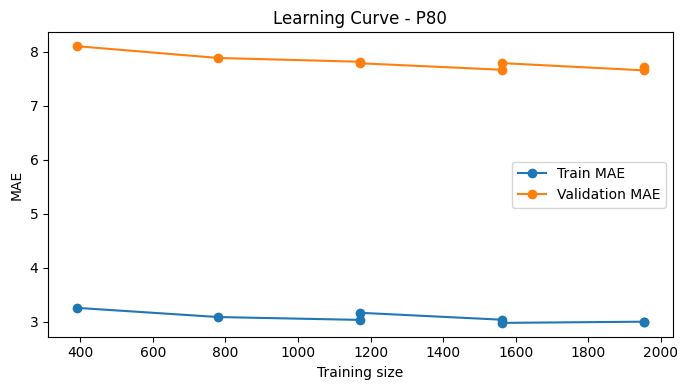

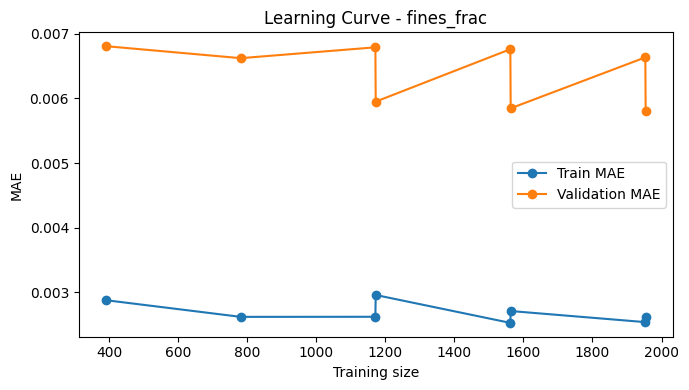

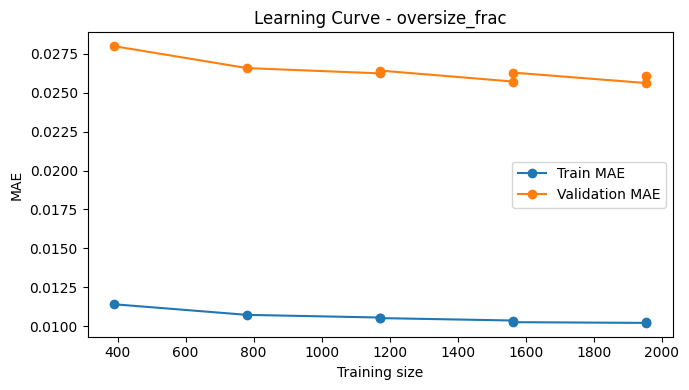

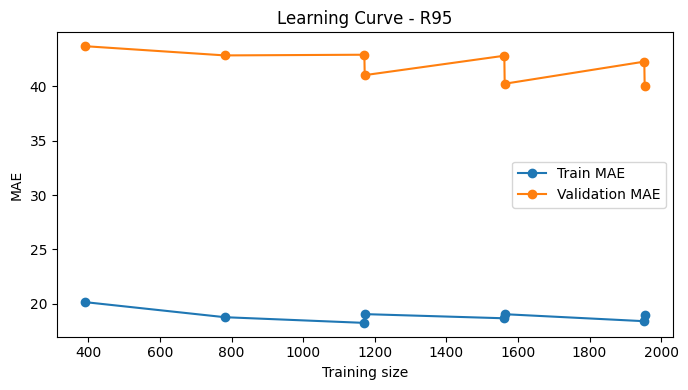

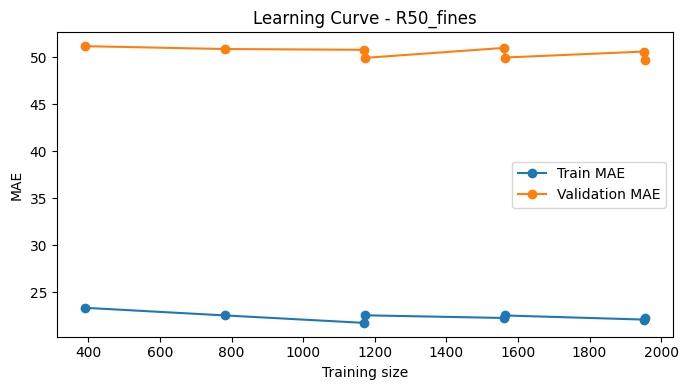

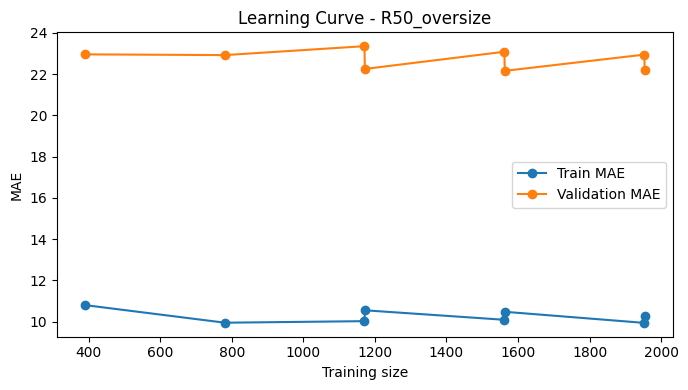

In [8]:
def learning_curve_diagnostics(
    X_raw, y_df, train_fracs=(0.2, 0.4, 0.6, 0.8, 1.0),
    n_splits=3, random_state=42, n_estimators=300
):
    rng = np.random.default_rng(random_state)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    rows = []
    for frac in train_fracs:
        for fold, (tr_idx, va_idx) in enumerate(kf.split(X_raw), start=1):
            if frac < 1.0:
                n_sub = max(50, int(len(tr_idx) * frac))
                sub_idx = rng.choice(tr_idx, size=n_sub, replace=False)
            else:
                sub_idx = tr_idx
            X_tr = X_raw.iloc[sub_idx].reset_index(drop=True)
            y_tr = y_df.iloc[sub_idx].reset_index(drop=True)
            X_va = X_raw.iloc[va_idx].reset_index(drop=True)
            y_va = y_df.iloc[va_idx].reset_index(drop=True)
            model = FinalForwardPipeline(final_target_config, random_state=random_state + fold + int(frac * 1000), n_estimators=n_estimators)
            model.fit(X_tr, y_tr)
            pred_tr = model.predict(X_tr)
            pred_va = model.predict(X_va)
            for target in target_cols:
                rows.append({
                    "train_frac": frac,
                    "train_size": len(X_tr),
                    "fold": fold,
                    "target": target,
                    "train_MAE": mean_absolute_error(y_tr[target], pred_tr[target]),
                    "valid_MAE": mean_absolute_error(y_va[target], pred_va[target]),
                })
    return pd.DataFrame(rows)

RUN_LEARNING_CURVES = True
if RUN_LEARNING_CURVES:
    learning_df = learning_curve_diagnostics(raw_train, y, n_splits=3, n_estimators=300)
    learning_summary = learning_df.groupby(["target", "train_frac", "train_size"]).agg(
        train_MAE=("train_MAE", "mean"),
        valid_MAE=("valid_MAE", "mean"),
    ).reset_index()
    display(learning_summary)
    
    for target in target_cols:
        temp = learning_summary[learning_summary["target"] == target]
        plt.figure(figsize=(7, 4))
        plt.plot(temp["train_size"], temp["train_MAE"], marker="o", label="Train MAE")
        plt.plot(temp["train_size"], temp["valid_MAE"], marker="o", label="Validation MAE")
        plt.title(f"Learning Curve - {target}")
        plt.xlabel("Training size")
        plt.ylabel("MAE")
        plt.legend()
        plt.tight_layout()
        fig_path = FIGURES_DIR / f"learning_curve_{target}.png"
        plt.savefig(fig_path, dpi=150)
        plt.show()
else:
    print("Skipped learning curves.")


## 6. Error analysis by regimes

The challenge data is physics-like and regime-dependent. We check whether errors concentrate in certain gravity or target regions.


In [9]:
def cross_validate_final_oof(X_raw, y_df, n_splits=5, random_state=42, n_estimators=800):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    oof = pd.DataFrame(index=y_df.index, columns=target_cols, dtype=float)
    for fold, (tr_idx, va_idx) in enumerate(kf.split(X_raw), start=1):
        print(f"OOF fold {fold}/{n_splits}")
        X_tr = X_raw.iloc[tr_idx].reset_index(drop=True)
        y_tr = y_df.iloc[tr_idx].reset_index(drop=True)
        X_va = X_raw.iloc[va_idx].reset_index(drop=True)
        model = FinalForwardPipeline(final_target_config, random_state=random_state + fold, n_estimators=n_estimators)
        model.fit(X_tr, y_tr)
        pred_va = model.predict(X_va)
        pred_va.index = va_idx
        oof.loc[va_idx, target_cols] = pred_va[target_cols]
    return oof

RUN_FULL_OOF = True
if RUN_FULL_OOF:
    final_oof = cross_validate_final_oof(raw_train, y, n_splits=5, n_estimators=800)
    overall_metrics = []
    for target in target_cols:
        m = regression_metrics(y[target], final_oof[target], target_name=target)
        m["target"] = target
        overall_metrics.append(m)
    final_oof_metrics = pd.DataFrame(overall_metrics)
    display(final_oof_metrics.sort_values("normalized_MAE"))
    display(pd.DataFrame([custom_constraint_metrics(y, final_oof)]))
else:
    print("Skipped full OOF generation.")


OOF fold 1/5
OOF fold 2/5
OOF fold 3/5
OOF fold 4/5
OOF fold 5/5


,MAE,RMSE,R2,Median_AE,P90_AE,P95_AE,Max_AE,Bias,normalized_MAE,normalized_RMSE,target
2,0.025680,0.035189,0.990552,0.018655,0.057401,0.075011,0.167200,-0.000040,0.070923,0.097185,oversize_frac
1,0.006317,0.013826,0.959368,0.000613,0.019765,0.031609,0.141095,-0.000035,0.092084,0.201540,fines_frac
0,7.649464,10.159581,0.976120,5.889286,16.804011,21.487673,53.412408,-0.005756,0.116332,0.154506,P80
3,41.432050,68.507429,0.917493,20.851114,103.401705,149.134690,471.617395,-0.366155,0.173688,0.287191,R95
4,50.393094,78.496171,0.898887,27.455684,129.306490,170.647824,533.891646,-0.386028,0.204104,0.317929,R50_fines
5,22.731340,38.575224,0.873407,11.680371,56.905391,81.580273,346.724231,-0.000924,0.209627,0.355739,R50_oversize


,n_true_feasible,n_pred_feasible,true_positive,false_positive,false_negative,feasible_precision,feasible_recall,feasible_f1,near_zone_count,near_zone_MAE_P80,near_zone_MAE_R95,near_zone_R95_bias
0,35,37,13,24,22,0.351351,0.371429,0.361111,372,4.584673,25.522959,13.911613


In [10]:
if RUN_FULL_OOF:
    regime_rows = []
    for target in distance_targets:
        temp = pd.DataFrame({
            "gravity": raw_train["gravity"],
            "true": y[target],
            "pred": final_oof[target],
        })
        temp["abs_error"] = np.abs(temp["pred"] - temp["true"])
        grouped = temp.groupby("gravity").agg(
            n=("abs_error", "size"),
            MAE=("abs_error", "mean"),
            Median_AE=("abs_error", "median"),
            true_mean=("true", "mean"),
            pred_mean=("pred", "mean"),
        ).reset_index()
        grouped["relative_MAE"] = grouped["MAE"] / (grouped["true_mean"].abs() + 1e-9)
        grouped["target"] = target
        regime_rows.append(grouped)
    gravity_error_df = pd.concat(regime_rows, ignore_index=True)
    display(gravity_error_df.sort_values(["target", "gravity"]))

    # Error by target quantile bins
    bin_rows = []
    for target in target_cols:
        temp = pd.DataFrame({"true": y[target], "pred": final_oof[target]})
        temp["abs_error"] = np.abs(temp["pred"] - temp["true"])
        temp["bin"] = pd.qcut(temp["true"], q=5, duplicates="drop")
        grouped = temp.groupby("bin").agg(
            n=("abs_error", "size"),
            true_min=("true", "min"),
            true_max=("true", "max"),
            MAE=("abs_error", "mean"),
            P95_AE=("abs_error", lambda s: np.percentile(s, 95)),
            Bias=("pred", lambda s: np.nan),
        ).reset_index()
        # Compute bias separately for clarity
        grouped["Bias"] = temp.groupby("bin").apply(lambda d: (d["pred"] - d["true"]).mean()).values
        grouped["target"] = target
        bin_rows.append(grouped)
    target_bin_error_df = pd.concat(bin_rows, ignore_index=True)
    display(target_bin_error_df)
else:
    print("Run full OOF first.")


,gravity,n,MAE,Median_AE,true_mean,pred_mean,relative_MAE,target
3,1.62,990,99.483678,83.646296,617.765891,615.766157,0.161038,R50_fines
4,3.71,1000,37.385978,31.009655,231.088286,231.694523,0.161782,R50_fines
5,9.81,940,12.528665,10.314012,72.569602,72.827513,0.172643,R50_fines
6,1.62,990,45.026701,34.597045,251.674665,251.226288,0.178908,R50_oversize
7,3.71,1000,16.673095,12.774441,92.754582,93.072986,0.179755,R50_oversize
8,9.81,940,5.694999,4.167549,29.572605,29.703225,0.192577,R50_oversize
0,1.62,990,81.774829,64.558453,504.102546,502.183621,0.162219,R95
1,3.71,1000,30.692067,22.846911,186.685165,187.323232,0.164405,R95
2,9.81,940,10.368891,7.383320,59.900523,60.101410,0.173102,R95


,bin,n,true_min,true_max,MAE,P95_AE,Bias,target
0,"(57.264, 98.411]",586,57.265208,98.406718,4.127634,10.478898,1.716816,P80
1,"(98.411, 135.615]",586,98.411864,135.504120,5.204525,12.827028,-0.518046,P80
2,"(135.615, 210.857]",586,135.688758,210.845309,8.931028,21.934131,3.747278,P80
3,"(210.857, 234.953]",586,210.874402,234.950222,8.849094,21.985186,1.721529,P80
4,"(234.953, 326.837]",586,234.964659,326.836650,11.135039,28.103310,-6.696356,P80
5,"(-0.000857, 0.00101]",586,0.000143,0.001010,0.000161,0.000412,0.000108,fines_frac
6,"(0.00101, 0.00185]",586,0.001011,0.001853,0.000264,0.000704,0.000064,fines_frac
7,"(0.00185, 0.0179]",586,0.001855,0.017846,0.001108,0.003992,0.000388,fines_frac
8,"(0.0179, 0.0854]",586,0.017985,0.085432,0.008577,0.023098,0.003715,fines_frac
9,"(0.0854, 0.463]",586,0.085501,0.463369,0.021477,0.058821,-0.004451,fines_frac


## 7. Test-set distance-to-train diagnostics

This does not use labels from the test set. It checks whether test scenarios are far from training scenarios in normalized input space.

If many test samples are far from the train distribution, the leaderboard may be strongly out-of-distribution.


In [11]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(raw_train[input_cols])
test_scaled = scaler.transform(raw_test[input_cols])

nn = NearestNeighbors(n_neighbors=5)
nn.fit(train_scaled)
distances, indices = nn.kneighbors(test_scaled)

test_distance_df = pd.DataFrame({
    "scenario_id": np.arange(len(raw_test)),
    "nearest_train_distance": distances[:, 0],
    "mean_5nn_distance": distances.mean(axis=1),
})

display(test_distance_df.describe().T)
display(test_distance_df.sort_values("nearest_train_distance", ascending=False).head(20))

test_distance_df.to_csv(REPORTS_DIR / "test_distance_to_train_diagnostics.csv", index=False)


,count,mean,std,min,25%,50%,75%,max
scenario_id,492.0,245.500000,142.172431,0.000000,122.750000,245.500000,368.250000,491.000000
nearest_train_distance,492.0,0.560674,0.149600,0.182295,0.435030,0.580499,0.678606,0.889880
mean_5nn_distance,492.0,0.617684,0.143318,0.234674,0.506642,0.628117,0.726834,0.947235


,scenario_id,nearest_train_distance,mean_5nn_distance
51,51,0.889880,0.911174
478,478,0.885638,0.918664
234,234,0.864652,0.888289
447,447,0.859306,0.896924
342,342,0.853755,0.882081
466,466,0.846808,0.852712
76,76,0.841188,0.870589
108,108,0.836186,0.902173
310,310,0.833301,0.947235
304,304,0.828850,0.895867


## 8. Seed ensemble test

ExtraTrees can vary with random seed. A seed ensemble averages several independently trained final models.

This may improve stability and reduce variance, but it can also smooth extremes. We test it with OOF validation before creating a possible alternative submission.


In [12]:
class SeedEnsembleForwardModel:
    def __init__(self, seeds, n_estimators=500):
        self.seeds = list(seeds)
        self.n_estimators = n_estimators
        self.models_ = []

    def fit(self, X_raw, y_df):
        self.models_ = []
        for seed in self.seeds:
            model = FinalForwardPipeline(final_target_config, random_state=seed, n_estimators=self.n_estimators)
            model.fit(X_raw, y_df)
            self.models_.append(model)
        return self

    def predict(self, X_raw):
        preds = [m.predict(X_raw) for m in self.models_]
        avg = sum(preds) / len(preds)
        for target in target_cols:
            avg[target] = clip_predictions(avg[target], target)
        return avg[target_cols]


def cross_validate_seed_ensemble(X_raw, y_df, seeds=(42, 123, 2026), n_splits=5, n_estimators=400):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    oof = pd.DataFrame(index=y_df.index, columns=target_cols, dtype=float)
    for fold, (tr_idx, va_idx) in enumerate(kf.split(X_raw), start=1):
        print(f"Seed ensemble fold {fold}/{n_splits}")
        X_tr = X_raw.iloc[tr_idx].reset_index(drop=True)
        y_tr = y_df.iloc[tr_idx].reset_index(drop=True)
        X_va = X_raw.iloc[va_idx].reset_index(drop=True)
        model = SeedEnsembleForwardModel(seeds=[s + fold for s in seeds], n_estimators=n_estimators)
        model.fit(X_tr, y_tr)
        pred_va = model.predict(X_va)
        pred_va.index = va_idx
        oof.loc[va_idx, target_cols] = pred_va[target_cols]
    rows = []
    for target in target_cols:
        m = regression_metrics(y_df[target], oof[target], target_name=target)
        m["target"] = target
        m["strategy"] = "seed_ensemble"
        rows.append(m)
    return pd.DataFrame(rows), oof

RUN_SEED_ENSEMBLE_TEST = True
if RUN_SEED_ENSEMBLE_TEST:
    seed_ensemble_metrics, seed_ensemble_oof = cross_validate_seed_ensemble(
        raw_train, y, seeds=(42, 123, 2026), n_splits=5, n_estimators=400
    )
    display(seed_ensemble_metrics.sort_values("normalized_MAE"))
    display(pd.DataFrame([custom_constraint_metrics(y, seed_ensemble_oof)]))
else:
    print("Skipped seed ensemble test.")


Seed ensemble fold 1/5
Seed ensemble fold 2/5
Seed ensemble fold 3/5
Seed ensemble fold 4/5
Seed ensemble fold 5/5


,MAE,RMSE,R2,Median_AE,P90_AE,P95_AE,Max_AE,Bias,normalized_MAE,normalized_RMSE,target,strategy
2,0.025659,0.035182,0.990556,0.018859,0.057036,0.074912,0.171753,-0.000042,0.070863,0.097165,oversize_frac,seed_ensemble
1,0.006318,0.013820,0.959406,0.000615,0.019718,0.031151,0.140794,-0.000014,0.092096,0.201444,fines_frac,seed_ensemble
0,7.644836,10.150915,0.976160,5.905626,16.761808,21.431347,53.100279,-0.005659,0.116262,0.154374,P80,seed_ensemble
3,41.458759,68.623462,0.917213,20.939496,103.550317,149.591916,474.222378,-0.434781,0.173800,0.287677,R95,seed_ensemble
4,50.381958,78.480818,0.898926,27.312934,130.015482,171.513030,533.266134,-0.406770,0.204059,0.317866,R50_fines,seed_ensemble
5,22.752999,38.631274,0.873039,11.607101,56.625407,81.943392,347.958211,-0.007478,0.209827,0.356255,R50_oversize,seed_ensemble


,n_true_feasible,n_pred_feasible,true_positive,false_positive,false_negative,feasible_precision,feasible_recall,feasible_f1,near_zone_count,near_zone_MAE_P80,near_zone_MAE_R95,near_zone_R95_bias
0,35,37,13,24,22,0.351351,0.371429,0.361111,372,4.573176,25.498783,13.905866


## 9. MLP neural-network baseline

A neural network can sometimes help, but on small tabular datasets it often loses against tree models.

We test a conservative MLP:

- StandardScaler
- 2 hidden layers
- early stopping
- regularization
- target-specific models

This is only a challenger. We use it only if it clearly improves CV metrics.


In [13]:
def build_feature_matrix_for_target(X_raw, target):
    cfg = final_target_config[target]
    X_fe = PhysicsFeatureEngineer(use_advanced=(cfg["feature_version"] == "v2")).fit_transform(X_raw)
    return X_fe[cfg["features"]].copy()


def build_mlp(random_state=42):
    return Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(
            hidden_layer_sizes=(128, 64),
            activation="relu",
            solver="adam",
            alpha=1e-3,
            learning_rate_init=1e-3,
            max_iter=1200,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=40,
            random_state=random_state,
        )),
    ])


def cross_validate_mlp_targets(X_raw, y_df, n_splits=5, random_state=42):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    oof = pd.DataFrame(index=y_df.index, columns=target_cols, dtype=float)
    for target in target_cols:
        print(f"MLP target: {target}")
        X_target = build_feature_matrix_for_target(X_raw, target)
        for fold, (tr_idx, va_idx) in enumerate(kf.split(X_target), start=1):
            X_tr = X_target.iloc[tr_idx]
            X_va = X_target.iloc[va_idx]
            y_tr = y_df.iloc[tr_idx][target]
            model = build_mlp(random_state=random_state + fold)
            model.fit(X_tr, y_tr)
            pred = model.predict(X_va)
            pred = clip_predictions(pred, target)
            oof.loc[va_idx, target] = pred
    rows = []
    for target in target_cols:
        m = regression_metrics(y_df[target], oof[target], target_name=target)
        m["target"] = target
        m["strategy"] = "MLP"
        rows.append(m)
    return pd.DataFrame(rows), oof

RUN_MLP_BASELINE = True
if RUN_MLP_BASELINE:
    mlp_metrics, mlp_oof = cross_validate_mlp_targets(raw_train, y, n_splits=5, random_state=42)
    display(mlp_metrics.sort_values("normalized_MAE"))
    display(pd.DataFrame([custom_constraint_metrics(y, mlp_oof)]))
else:
    print("Skipped MLP baseline.")


MLP target: P80
MLP target: fines_frac
MLP target: oversize_frac
MLP target: R95
MLP target: R50_fines
MLP target: R50_oversize


,MAE,RMSE,R2,Median_AE,P90_AE,P95_AE,Max_AE,Bias,normalized_MAE,normalized_RMSE,target,strategy
2,0.030533,0.041740,0.986707,0.022888,0.066668,0.085644,0.208225,-0.000246,0.084325,0.115276,oversize_frac,MLP
0,7.752098,10.234798,0.975765,5.910997,17.168598,21.200102,46.907743,-0.160882,0.117893,0.155650,P80,MLP
1,0.011638,0.020746,0.908520,0.004233,0.033582,0.046532,0.183425,0.001427,0.169638,0.302404,fines_frac,MLP
3,40.678663,66.339735,0.922632,22.088666,101.742638,145.670856,538.295364,-1.767734,0.170530,0.278104,R95,MLP
4,50.385482,77.171212,0.902272,28.916030,129.299172,167.571308,518.436123,-0.441906,0.204073,0.312562,R50_fines,MLP
5,22.513873,37.779594,0.878575,11.708851,55.922547,79.778783,310.713890,0.090426,0.207622,0.348401,R50_oversize,MLP


,n_true_feasible,n_pred_feasible,true_positive,false_positive,false_negative,feasible_precision,feasible_recall,feasible_f1,near_zone_count,near_zone_MAE_P80,near_zone_MAE_R95,near_zone_R95_bias
0,35,35,10,25,25,0.285714,0.285714,0.285714,372,4.77549,23.794609,10.805939


## 10. Final comparison and recommendation

In [14]:
comparison_tables = []

if 'final_oof_metrics' in globals():
    temp = final_oof_metrics.copy()
    temp["strategy"] = "final_single_model"
    comparison_tables.append(temp)

if 'seed_ensemble_metrics' in globals():
    comparison_tables.append(seed_ensemble_metrics.copy())

if 'mlp_metrics' in globals():
    comparison_tables.append(mlp_metrics.copy())

if comparison_tables:
    all_strategy_metrics = pd.concat(comparison_tables, ignore_index=True)
    display(all_strategy_metrics.sort_values(["target", "MAE"])[[
        "strategy", "target", "MAE", "RMSE", "R2", "P95_AE", "normalized_MAE", "normalized_RMSE"
    ]])

    # Strategy-level aggregate. Lower is better for normalized MAE/RMSE/P95 proxy.
    strategy_summary = all_strategy_metrics.groupby("strategy").agg(
        mean_normalized_MAE=("normalized_MAE", "mean"),
        mean_normalized_RMSE=("normalized_RMSE", "mean"),
        mean_R2=("R2", "mean"),
        mean_P95_AE=("P95_AE", "mean"),
    ).reset_index().sort_values("mean_normalized_MAE")
    display(strategy_summary)
else:
    print("No comparison tables available. Run at least the final OOF diagnostics.")


,strategy,target,MAE,RMSE,R2,P95_AE,normalized_MAE,normalized_RMSE
6,seed_ensemble,P80,7.644836,10.150915,0.976160,21.431347,0.116262,0.154374
0,final_single_model,P80,7.649464,10.159581,0.976120,21.487673,0.116332,0.154506
12,MLP,P80,7.752098,10.234798,0.975765,21.200102,0.117893,0.155650
10,seed_ensemble,R50_fines,50.381958,78.480818,0.898926,171.513030,0.204059,0.317866
16,MLP,R50_fines,50.385482,77.171212,0.902272,167.571308,0.204073,0.312562
4,final_single_model,R50_fines,50.393094,78.496171,0.898887,170.647824,0.204104,0.317929
17,MLP,R50_oversize,22.513873,37.779594,0.878575,79.778783,0.207622,0.348401
5,final_single_model,R50_oversize,22.731340,38.575224,0.873407,81.580273,0.209627,0.355739
11,seed_ensemble,R50_oversize,22.752999,38.631274,0.873039,81.943392,0.209827,0.356255
15,MLP,R95,40.678663,66.339735,0.922632,145.670856,0.170530,0.278104


,strategy,mean_normalized_MAE,mean_normalized_RMSE,mean_R2,mean_P95_AE
1,final_single_model,0.144460,0.235681,0.935971,70.492847
2,seed_ensemble,0.144485,0.235797,0.935884,70.764291
0,MLP,0.159014,0.252066,0.929078,69.058871


## 11. Optional: create alternative seed-ensemble submission

Only set `CREATE_SEED_ENSEMBLE_SUBMISSION = True` if the seed ensemble clearly beats the final single model on OOF metrics.

The official `prediction_submission.csv` from notebook 09 is not overwritten here. The alternative file is saved separately.


In [15]:
CREATE_SEED_ENSEMBLE_SUBMISSION = False

if CREATE_SEED_ENSEMBLE_SUBMISSION:
    ensemble_model = SeedEnsembleForwardModel(seeds=(42, 123, 2026, 777, 2024), n_estimators=800)
    ensemble_model.fit(raw_train, y)
    test_pred_ensemble = ensemble_model.predict(raw_test)
    submission_ensemble = pd.DataFrame({"scenario_id": np.arange(len(raw_test))})
    for col in target_cols:
        submission_ensemble[col] = test_pred_ensemble[col].values
    submission_ensemble = submission_ensemble[["scenario_id"] + target_cols]
    ensemble_path = SUBMISSIONS_DIR / "prediction_submission_seed_ensemble_candidate.csv"
    submission_ensemble.to_csv(ensemble_path, index=False)
    print("Saved seed ensemble candidate submission to:", ensemble_path)
    print(submission_ensemble.shape)
    display(submission_ensemble.head())
else:
    print("Seed ensemble submission creation is disabled by default.")


Seed ensemble submission creation is disabled by default.


## 12. Recommended decision logic

Use this final checklist:

1. Keep notebook 09 submission if the final single model is best or tied.
2. Use a seed ensemble only if it improves most key targets and does not worsen P95/RMSE materially.
3. Do not use MLP unless it clearly wins on CV across MAE, RMSE, P95, and near-zone metrics.
4. If learning curves show large overfitting, prefer the seed ensemble or more conservative tree settings.
5. If learning curves show validation is still improving with more data, the model is data-limited; no algorithm will fully solve that.

For one-shot competition submission, prefer robustness over a tiny metric gain.
